In [5]:
import numpy as np
import pandas as pd

data = pd.read_csv('../data/clean_weather.csv')
data.head(3)

,Unnamed: 0,tmax,tmin,rain,tmax_tomorrow
0,1970-01-01,60.0,35.0,0.0,52.0
1,1970-01-02,52.0,39.0,0.0,52.0
2,1970-01-03,52.0,35.0,0.0,53.0


In [6]:
data.isna().sum()

Unnamed: 0         0
tmax              11
tmin              14
rain             281
tmax_tomorrow     11
dtype: int64

In [7]:
data = data.ffill()

In [8]:
data.isna().sum()

Unnamed: 0       0
tmax             0
tmin             0
rain             0
tmax_tomorrow    0
dtype: int64

In [9]:
import numpy as np

data["tmax"].head(10).to_numpy()[np.newaxis, :].shape

(1, 10)

### Random Weights for network

In [10]:
np.random.seed(0)

w_input = np.random.rand(1, 2)
w_hidden = np.random.rand(2, 2)
w_output = np.random.rand(2, 1)

temps = data["tmax"].tail(3).to_numpy()
temps

array([66., 70., 62.])

In [11]:
x0 = temps[0].reshape(1, 1)
x1 = temps[1].reshape(1, 1)
x2 = temps[2].reshape(1, 1)

In [12]:
print(x0.shape)
x0

(1, 1)


array([[66.]])

In [13]:
print(w_input.shape)
w_input

(1, 2)


array([[0.5488135 , 0.71518937]])

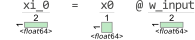

array([[36.22169126, 47.20249818]])

In [14]:
from tsensor import explain as exp

with exp():
    xi_0 = x0 @ w_input
xi_0

### Relu activation

In [15]:
def relu(input):
    return np.maximum(0, input)

In [16]:
xh_0 = relu(xi_0)

xh_0

array([[36.22169126, 47.20249818]])

In [17]:
xo_0 = xh_0 @ w_output

xo_0

array([[57.94406231]])

In [18]:
xi_1 = x1 @ w_input

xi_1

array([[38.41694527, 50.06325565]])

In [19]:
xh = xh_0 @ w_hidden

xh

array([[41.83067381, 50.22440612]])

In [20]:
xh_1 = relu(xh + xi_1)

xh_1

array([[ 80.24761908, 100.28766177]])

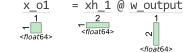

array([[124.54916092]])

In [21]:
with exp():
    x_o1 = xh_1 @ w_output

x_o1

In [22]:
xi_2 = x2 @ w_input

xh = xh_1 @ w_hidden

xh_2 = relu(xh + xi_2)

xo_2 = xh_2 @ w_output

xo_2


array([[190.94853131]])

#### Nonlinearity

You may have noticed that the output values increased in each time step of our RNN. That's because the hidden states kept getting larger and larger. Unlike the sigmoid or softmax activation functions, relu doesn't change the scale of the inputs at all (it just sets some to 0). This means that some values get repeatedly multiplied and grow larger and larger.

In [23]:
xh_0

array([[36.22169126, 47.20249818]])

In [24]:
xh_1

array([[ 80.24761908, 100.28766177]])

In [25]:
xh_2

array([[124.88411227, 152.84252918]])

### tanh function instead of Relu to fix this

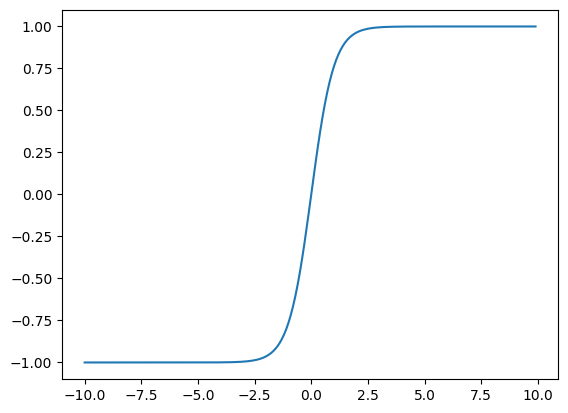

In [26]:
import matplotlib.pyplot as plt
# Define some temperature values
temps = np.arange(-10, 10, .1)

# Plot the tanh of the values
plt.plot(temps, np.tanh(temps))

### Get Gradient

In [27]:
from sympy import diff, symbols, exp

x = symbols("x")
sympy_tanh = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
diff(sympy_tanh, x)

(-exp(x) + exp(-x))*(exp(x) - exp(-x))/(exp(x) + exp(-x))**2 + 1

### The Derivative

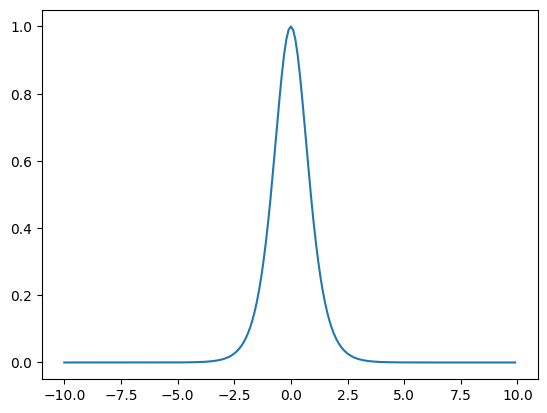

In [28]:
plt.plot(temps, 1 - np.tanh(temps) ** 2)

### Full Forward

In [29]:
np.random.seed(0)

# Define our weights and biases
# Scale them down so values get through the tanh nonlinearity
wieght_input = np.random.rand(1,5) / 5 - .1
wieght_hidden = np.random.rand(5,5) / 5 - .1
bias_hidden = np.random.rand(1,5) / 5 - .1

# Tanh pushes values to between -1 and 1, so scale up the output weights
weight_output = np.random.rand(5,1) * 50
bias_output = np.random.rand(1,1)

In [30]:
def tanh(input):
    return np.tanh(input)

In [31]:
# An array to store the output predictions
outputs = np.zeros(3)
# An array to store hidden states for use in backpropagation
hiddens = np.zeros((3, 5))

# This will store the previous hidden state, since we'll need it to calculate the current hidden step
prev_hidden = None
sequence = data["tmax"].tail(3).to_numpy()

for i in range(3):
    x = sequence[i].reshape(1, 1)

    x_i = x @ wieght_input

    if prev_hidden is None:
        xh = x_i

    else:
        xh = x_i + prev_hidden @ wieght_hidden + bias_hidden

    xh_i = tanh(xh)

    prev_hidden = xh_i

    hiddens[i, ] = xh_i

    xo_i = xh_i @ weight_output + bias_output

    outputs[i] = xo_i




C:\Users\moham\AppData\Local\Temp\ipykernel_10228\3857473750.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  outputs[i] = xo_i


#### tanh is better than Relu
##### Values are near to eachother

In [32]:
outputs

array([74.31470595, 80.66149404, 77.67852446])

In [33]:
hiddens

array([[ 0.56784618,  0.99320288,  0.87557333,  0.53166114, -0.76483255],
       [ 0.58366756,  0.99568651,  0.90034879,  0.69338529, -0.84149203],
       [ 0.5383306 ,  0.99164251,  0.86287584,  0.66091071, -0.80543591]])

## Loss Calculation

In [36]:
def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)

def mse_grad(actual, predicted):
    return (predicted - actual)

In [39]:
actual = np.array([70, 62, 65])

loss_grad = mse_grad(actual, outputs)
loss_grad

array([ 4.31470595, 18.66149404, 12.67852446])

## Backpropagation

#### Step by Step

In [83]:
next_hidden = None

grad_weight_output, grad_bias_output, grad_weight_hidden, grad_bias_hidden, grad_weight_input = [0] * 5

In [84]:
l2_grad = loss_grad[2].reshape(1, 1)
l2_grad


array([[12.67852446]])

In [85]:
print(grad_weight_output)
grad_weight_output += hiddens[2][:, np.newaxis] @ l2_grad
grad_weight_output

0


array([[  6.82523764],
       [ 12.57256386],
       [ 10.93999241],
       [  8.37937265],
       [-10.21173885]])

In [87]:
print(grad_bias_output)
grad_bias_output += np.mean(l2_grad)
grad_bias_output

0


np.float64(12.678524458390228)

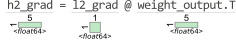

array([[391.5353378 , 388.02352957, 391.09063843, 598.2666548 ,
        432.22376692]])

In [88]:
from tsensor import explain as exp
with exp():
    h2_grad = l2_grad @ weight_output.T

h2_grad

In [89]:
tanh_deriv = 1 - hiddens[2, :][np.newaxis, :] ** 2
tanh_deriv

array([[0.71020017, 0.01664513, 0.25544529, 0.56319703, 0.351273  ]])

In [90]:
# a = h2_grad * tanh_deriv
#
# b = np.multiply(h2_grad, tanh_deriv)
#
# a == b

h2_grad = np.multiply(h2_grad, tanh_deriv)

h2_grad

array([[278.06846268,   6.45870031,  99.90226127, 336.94200237,
        151.82853915]])

In [91]:
print(grad_weight_hidden)

grad_weight_hidden += hiddens[1, :][:, np.newaxis] @ h2_grad

grad_weight_hidden

0


array([[ 162.29954086,    3.76973385,   58.30970898,  196.66211606,
          88.61739284],
       [ 276.8690166 ,    6.43084076,   99.47133367,  335.48860575,
         151.17362797],
       [ 250.35860451,    5.81508303,   89.94688027,  303.36532487,
         136.69864184],
       [ 192.80858163,    4.47836779,   69.2707584 ,  233.63062802,
         105.27567565],
       [-233.99239488,   -5.43494483,  -84.06695654, -283.53400925,
        -127.76250548]])

In [92]:
print(grad_bias_hidden)
grad_bias_hidden += np.mean(h2_grad)
grad_bias_hidden

0


np.float64(174.63999315855165)

In [93]:
print(grad_weight_input)
grad_weight_input += sequence[2].reshape(1, 1).T @ h2_grad
grad_weight_input

0


array([[17240.24468627,   400.43941938,  6193.94019879, 20890.40414712,
         9413.36942759]])

In [42]:
for i in range(2, -1, -1):
    l_grad = loss_grad[i].reshape(1, 1)

    grad_weight_output = hiddens[i][:, np.newaxis] @ l_grad
    grad_bias_out = np.mean(l_grad)
